## Gradient Descent Extensions: Momentum and Adam

In this laboratory session, you will explore two popular extensions of basic Gradient Descent:
1.	Momentum-based Gradient Descent
2.	Adam (Adaptive Moment Estimation)

We will test these methods on three classical benchmark functions in 2D space:
- **Sphere**: a simple, convex, unimodal function that is relatively easy to optimize.
- **Rosenbrock**: features a narrow valley, making convergence more difficult.
- **Rastrigin**: contains many local minima, making it challenging to escape suboptimal points.

By the end of this lab, you should understand how momentum and adaptive step-size techniques help accelerate gradient-based optimization, especially on surfaces with poor curvature or local traps.

### Test Functions
You have been given implementations of the three test functions (Sphere, Rosenbrock, and Rastrigin) along with their gradients, all inheriting from the abstract `Problem` class.

In [1]:
import numpy as np
from abc import ABC, abstractmethod


class Problem(ABC):
    @abstractmethod
    def __call__(self, x: np.ndarray) -> float:
        """Compute the function value at point x."""
        raise NotImplementedError

    @abstractmethod
    def grad(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient at point x."""
        raise NotImplementedError

class Sphere(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(x**2)

    def grad(self, x: np.ndarray) -> np.ndarray:
        return 2 * x

class Rosenbrock(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

    def grad(self, x: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(x)
        n = x.size
        grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
        for i in range(1, n - 1):
            grad[i] = 200 * (x[i] - x[i-1]**2) - 400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        grad[-1] = 200 * (x[-1] - x[-2]**2)
        return grad

class Rastrigin(Problem):
    def __call__(self, x: np.ndarray) -> float:
        A = 10
        n = x.size
        return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

    def grad(self, x: np.ndarray) -> np.ndarray:
        A = 10
        return 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)


### Visualization Tools
Here are some already implemented functions that you can use to produce visualizations:

In [17]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def prepare_mesh_grid(
    problem: Problem,
    bounds: tuple[float, float] = (-5.0, 5.0),
    grid_size: int = 50,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_vals = np.linspace(bounds[0], bounds[1], grid_size)
    y_vals = np.linspace(bounds[0], bounds[1], grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(grid_size):
        for j in range(grid_size):
            xy = np.array([X[i, j], Y[i, j]])
            Z[i, j] = problem(xy)

    return X, Y, Z, x_vals, y_vals


def plot_3d_surface(
    problem: Problem,
    grid_size: int = 50,
):
    X, Y, Z, _, _ = prepare_mesh_grid(problem=problem, grid_size=grid_size)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_title(problem.__class__.__name__)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.show()

def plot_contour_and_paths(
    problem: Problem,
    paths: list[np.ndarray],
    grid_size: int = 200,
    title: str = "",
):
    """
    Create an interactive contour plot of a 2D function and overlay multiple optimization paths.

    Args:
        problem: An instance of a Problem class.
        paths: List of numpy arrays; each array is of shape (epochs, 2) containing an optimization trajectory.
        title: Title for the plot.
    """
    _, _, Z, x_vals, y_vals = prepare_mesh_grid(problem, grid_size=grid_size)

    fig = go.Figure(
        data=go.Contour(
            x=x_vals,
            y=y_vals,
            z=Z,
            colorscale="Viridis",
            contours=dict(showlines=False),
            colorbar=dict(title="Function Value"),
        )
    )

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'pink', 'brown']

    for idx, path in enumerate(paths):
        color_idx = idx % len(colors)
        fig.add_trace(
            go.Scatter(
                x=path[:, 0],
                y=path[:, 1],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(width=2, color=colors[color_idx]),
                name=f"Run {idx+1}",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=title,title_x=0.5, xaxis_title="x", yaxis_title="y", width=800, height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

### 1. Getting familiar with optimization test problems
Understand the landscapes of the test functions to predict optimization challenges.
Visualize each function. Use `plot_3d_surface` to generate a 3D surface plot for each function (Sphere, Rosenbrock, Rastrigin). Use `plot_contour_and_paths` with an empty paths list to generate a 2D contour plot for each function.

Which function appears easiest to optimize? Hardest? Why?

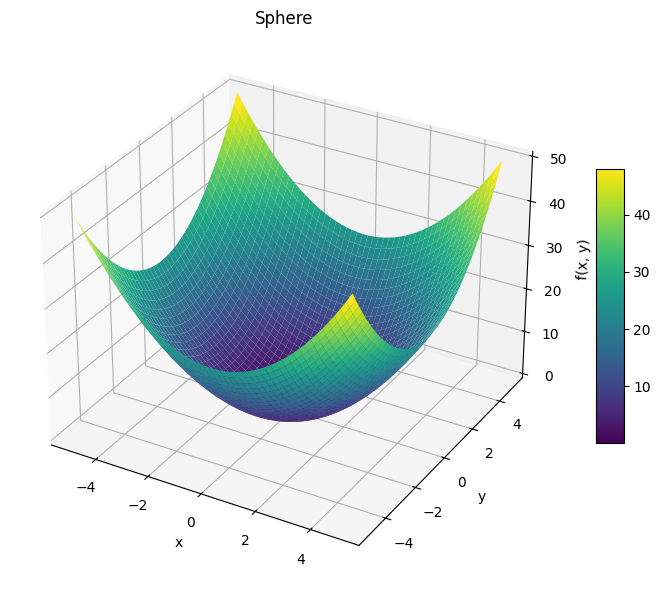

In [3]:
plot_3d_surface(problem=Sphere())

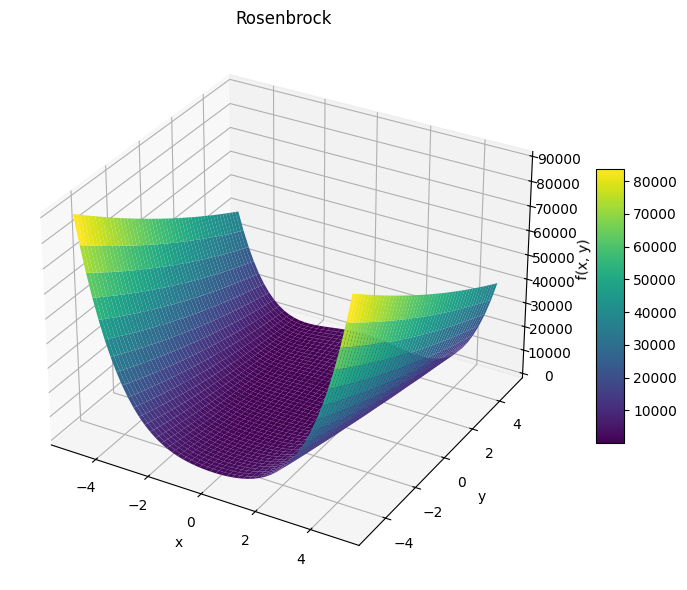

In [4]:
plot_3d_surface(problem=Rosenbrock())

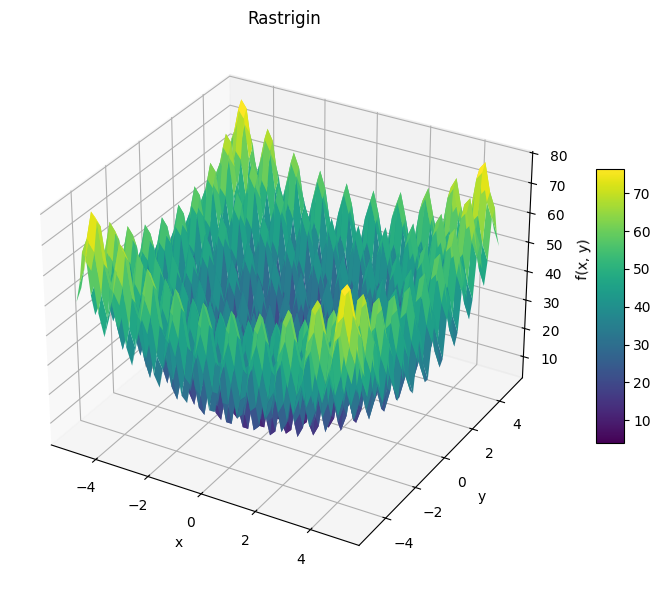

In [5]:
plot_3d_surface(problem=Rastrigin())


### 2. Momentum method

Your task is to implement the Momentum optimizer with the interface:
```python
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
):
    ...
```
Where:
- initial_solution is your starting point.
- alpha is the learning rate.
- beta is the momentum parameter (commonly 0.9).

### 3. Experiments with Momentum

Observe how Momentum performs on different functions. Use following parameters:
- `initial_solution = np.array([2.0, 2.0])`,
- `alpha = 0.01`,
- `beta = 0.9`,
- `number_of_epochs = 100`.

For each function, plot:
- Function value vs. epoch.
- For Rosenbrock and Rastrigin functions, experiment with decreasing the learning rate `alpha` (try values like 0.001 and 0.0001) to observe how it affects convergence.
- Velocity norm (e.g `np.linalg.norm`) vs. epoch.

How does the velocity norm evolve? Does it correlate with convergence speed?

In [7]:
from plotly.subplots import make_subplots


def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int
):
    velocity = np.zeros_like(initial_solution)
    parameter = initial_solution.copy()

    parameter_to_epoch = [parameter.copy()]
    velocity_norm_to_epoch = [np.linalg.norm(velocity)]

    for _ in range(number_of_epochs):
        velocity = beta * velocity + alpha * problem.grad(parameter)
        parameter = parameter - velocity
        parameter_to_epoch.append(parameter.copy())
        velocity_norm_to_epoch.append(np.linalg.norm(velocity))

    return np.array(parameter_to_epoch), np.array(velocity_norm_to_epoch)



def show_momentum_plots(problem, parameter_to_epoch, velocity_norm_to_epoch, extra_text = None):

    epochs = list(range(len(parameter_to_epoch)))
    function_values = [problem(x) for x in parameter_to_epoch]

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Function value vs epoch", "Velocity norm vs epoch")
    )

    fig.add_trace(
        go.Scatter(x=epochs, y=function_values, mode="lines", name="f(x)"),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(x=epochs, y=velocity_norm_to_epoch, mode="lines", name="||v||"),
        row=1, col=2
    )

    fig.update_xaxes(title_text="Epoch", row=1, col=1)
    fig.update_yaxes(title_text="Function value", row=1, col=1)

    fig.update_xaxes(title_text="Epoch", row=1, col=2)
    fig.update_yaxes(title_text="Velocity norm", row=1, col=2)

    fig.update_layout(
        width=1000,
        height=400,
        title=f"Momentum metrics on {problem.__class__.__name__} {extra_text}",
        title_x=0.5
    )

    fig.show()


In [8]:
parameter_to_epoch, velocity_norm_to_epoch = momentum(
    problem=Sphere(),
    initial_solution=np.array([2.0, 2.0]),
    alpha=0.01,
    beta=0.9,
    number_of_epochs=100
)

show_momentum_plots(
    problem=Sphere(),
    parameter_to_epoch=parameter_to_epoch,
    velocity_norm_to_epoch=velocity_norm_to_epoch
)



In [9]:
parameter_to_epoch, velocity_norm_to_epoch = momentum(
    problem=Rosenbrock(),
    initial_solution=np.array([2.0, 2.0]),
    alpha=0.0001,
    beta=0.9,
    number_of_epochs=100
)

show_momentum_plots(
    problem=Rosenbrock(),
    parameter_to_epoch=parameter_to_epoch,
    velocity_norm_to_epoch=velocity_norm_to_epoch
)

In [10]:
parameter_to_epoch, velocity_norm_to_epoch = momentum(
    problem=Rastrigin(),
    initial_solution=np.array([2.0, 2.0]),
    alpha=0.001,
    beta=0.9,
    number_of_epochs=100
)


show_momentum_plots(
    problem=Rastrigin(),
    parameter_to_epoch=parameter_to_epoch,
    velocity_norm_to_epoch=velocity_norm_to_epoch
)


### 4. Momentum Hyperparameters

Fix `alpha = 1e-4, initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
Use $\beta \in [0.5, 0.75, 0.9, 0.95, 0.99]$ on the Rosenbrock function. How does increasing $\beta$ affect convergence? Stability?

In [11]:
beta = [0.5, 0.75, 0.9, 0.95, 0.99]

for b in beta:
    parameter_to_epoch, velocity_norm_to_epoch = momentum(
    problem=Rosenbrock(),
    initial_solution=np.array([2.0, 2.0]),
    alpha=1e-4,
    beta=b,
    number_of_epochs=100
    )

    show_momentum_plots(
        problem=Rosenbrock(),
        parameter_to_epoch=parameter_to_epoch,
        velocity_norm_to_epoch=velocity_norm_to_epoch,
        extra_text=f'with beta={b}'
    )


### 5. Adam
Implement the Adam optimizer:

```python
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
):
    ...
```

Where:
- beta1 is the exponential decay rate for first moment estimates (similar to momentum).
- beta2 is the exponential decay rate for second moment estimates (variance).

In [14]:
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
):
    first_moment = np.zeros_like(initial_solution)
    second_moment = np.zeros_like(initial_solution)
    parameter = initial_solution.copy()
    value_to_epoch = [parameter.copy()]

    for e in range(number_of_epochs):
        first_moment = beta1 * first_moment + (1-beta1)*problem.grad(parameter)
        second_moment =  beta2 * second_moment + (1-beta2) * (problem.grad(parameter))**2
        first_moment_bias_corrected = first_moment / (1 - beta1 ** (e+1))
        second_moment_bias_corrected = second_moment / (1 - beta2 ** (e+1))
        parameter = parameter - alpha * first_moment_bias_corrected  / (second_moment_bias_corrected**0.5 +  epsilon)
        value_to_epoch.append(parameter.copy())

    return np.array(value_to_epoch)




### 6. Comparing Adam with Momentum
Run both optimizers on Sphere, Rosenbrock and Rastrigin. Use:
- `initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
- Momentum: `alpha = 0.01, beta = 0.9`.
- Adam: `alpha = 0.01, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8`.


Visualize optimization paths. Use `plot_contour_and_paths` to overlay paths from both methods.
Plot function value vs. epoch for both methods.

In [21]:
problems = [Sphere(), Rosenbrock(), Rastrigin()]

for problem in problems:
    momentum_value_to_epoch, _ = momentum(
        problem=problem,
        initial_solution=np.array([2.0, 2.0]),
        number_of_epochs=100,
        alpha=0.001 if isinstance(problem, Rosenbrock) else 0.01,
        beta=0.9
    )
    adam_value_to_epoch = adam(
        problem=problem,
        initial_solution=np.array([2.0, 2.0]),
        number_of_epochs=100,
        alpha=0.01,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8
    )

    plot_contour_and_paths(
        problem=problem,
        paths=[momentum_value_to_epoch, adam_value_to_epoch],
        title=f'Momentum vs adam on {problem.__class__.__name__}'
    )